# Example 3 — Koopman–Luenberger Observer for the Lorenz Chaotic System

We apply the data-driven Koopman–Luenberger observer to the three-state Lorenz system

$$
\dot{x}_1 = 10(x_2 - x_1), \qquad
\dot{x}_2 = x_1(28 - x_3) - x_2, \qquad
\dot{x}_3 = x_1 x_2 - \tfrac{8}{3}\,x_3, \qquad
y = \begin{pmatrix}x_1\\x_3\end{pmatrix}.
$$

The origin $x^*=(0,0,0)$ is an unstable equilibrium; the two off-origin equilibria
$C^\pm = (\pm 6\sqrt{2},\,\pm 6\sqrt{2},\,27)$ are also unstable.
The system exhibits a **strange (chaotic) attractor** with approximate bounds
$x_1\in[-18,18]$, $x_2\in[-25,25]$, $x_3\in[4,46]$.

Measuring both $x_1$ and $x_3$ makes the system **fully linearly observable**:
the observability matrix $\mathcal{O} = [C^\top,\,(CA)^\top]^\top$ has rank 3.

**Data sampling strategy (attractor-based):**
Initial conditions are first drawn from a hypercube, then each trajectory is integrated
forward for `burn_in` seconds so all basis points land on/near the strange attractor.

**Workflow:**
1. Set all hyperparameters in the `HP` dictionary (next cell)
2. Run all remaining cells in order — each step is timed and a summary table is printed at the end


In [1]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from dynamical_system import DynamicalSystem, synthesize_observer_gain, simulate_koopman_observer
from kernel import linear_kernel, sobolev_kernel

warnings.filterwarnings("ignore")
timings = {}   # wall-clock times filled in by each step cell

## Hyperparameters

Edit **only this cell** to explore the effect of each hyperparameter.
All downstream cells read from `HP` and require no further edits.

| Key | Symbol | Role |
|---|---|---|
| `lam` | $\lambda$ | Yosida regularisation parameter |
| `tau` | $\tau$ | Trajectory duration used for the Yosida integral (s) |
| `n` | $n$ | Number of basis (data) points |
| `side_lengths` | $[L_1,L_2,L_3]$ | Initial hypercube for burn-in sampling: $x_i\in[-L_i/2,\,L_i/2]$ |
| `burn_in` | $T_{\rm burn}$ | Warm-up time (s): each IC is run forward for $T_{\rm burn}$ s to reach the attractor |
| `s` | $s$ | Sobolev index of the kernel $\kappa_{\mathrm{Sob}}$ (smoothness) |
| `length_scale` | $\ell$ | Length scale of the Sobolev kernel (set to match attractor scale) |
| `k` | $k$ | Forcing constant in the LMI (paper Eq. 19) |
| `eps` | $\varepsilon$ | Gram-matrix regularisation: $G \leftarrow K_0 + \varepsilon I$ |
| `delta` | $\delta$ | Strict PD lower bound on $\tilde{P}$: $\tilde{P} \succ \delta I$ |
| `margin` | — | Strict negativity margin in the LMI: $\preceq -\text{margin}\cdot I$ |


In [2]:
HP = {
    # ── Yosida approximation ──────────────────────────────────────────────
    "lam":          5.0,            # λ
    "tau":          3.0,            # τ  (seconds)
    # ── Data ─────────────────────────────────────────────────────────────
    "n":            64,             # number of basis points
    "side_lengths": [40., 52., 92.],# initial sampling box (before burn-in)
    "burn_in":      10.0,           # warm-up: run each IC forward 10 s to reach attractor
    # ── Kernel ───────────────────────────────────────────────────────────
    "s":            2.5,            # Sobolev index
    "length_scale": 3.0,            # ℓ — matches local attractor scale (pairwise dist median~17, tuned to 3)
    # ── LMI ──────────────────────────────────────────────────────────────
    "k":            10.0,           # forcing constant (paper Eq. 19)
    "eps":          1e-2,           # Gram-matrix regularisation
    "delta":        1.0,            # P̃ ≻ δ I
    "margin":       1e-2,           # LMI strict negativity margin
}


## System definition

In [3]:
def f_ex3(x):
    return np.array([
        10.0 * (x[1] - x[0]),
        x[0] * (28.0 - x[2]) - x[1],
        x[0] * x[1] - (8.0 / 3.0) * x[2],
    ])

sys3 = DynamicalSystem(
    f=f_ex3,
    h=lambda x: np.array([x[0], x[2]]),   # y = [x1, x3]
    n_states=3, n_outputs=2,
    name="Ex3-Lorenz",
)

# Sanity check: equilibrium and Jacobian eigenvalues at origin
print(f"f(0,0,0) = {f_ex3(np.zeros(3))}  (should be [0,0,0])")
J0 = np.array([[-10., 10., 0.], [28., -1., 0.], [0., 0., -8./3.]])
eigs = np.linalg.eigvals(J0)
print(f"Jacobian eigenvalues at origin: {np.sort(eigs.real)}")
print(f"  (one positive → unstable saddle; strange attractor exists)")

# Observability check with y = [x1, x3]
C_obs = np.array([[1., 0., 0.], [0., 0., 1.]])
O_mat = np.vstack([C_obs, C_obs @ J0])   # (4, 3)
print(f"\nObservability matrix O (4×3):\n{O_mat}")
print(f"rank(O) = {np.linalg.matrix_rank(O_mat)}  (= 3 → fully observable)")


f(0,0,0) = [0. 0. 0.]  (should be [0,0,0])
Jacobian eigenvalues at origin: [-22.82772345  -2.66666667  11.82772345]
  (one positive → unstable saddle; strange attractor exists)

Observability matrix O (4×3):
[[  1.           0.           0.        ]
 [  0.           0.           1.        ]
 [-10.          10.           0.        ]
 [  0.           0.          -2.66666667]]
rank(O) = 3  (= 3 → fully observable)


## Step 1 — Data collection

In [4]:
t_eval_data = np.linspace(0.0, HP["tau"], 31)   # 31 points shared across trajectories

t0 = time.perf_counter()
data3 = sys3.collect_data(
    side_lengths=HP["side_lengths"],
    n=HP["n"],
    tau=HP["tau"],
    t_eval=t_eval_data,
    burn_in=HP["burn_in"],
    rng=np.random.default_rng(0),
)
timings["1. Data collection"] = time.perf_counter() - t0

print(f"Data collection : {timings['1. Data collection']:.3f} s  (incl. {HP['burn_in']:.0f} s burn-in per IC)")
print(f"  n_samples     : {data3.n_samples}")
print(f"  X_data shape  : {data3.X_data.shape}")
print(f"  Y_data shape  : {data3.Y_data.shape}")

# Show where the burn-in ICs landed on the attractor
x1_range = f"[{data3.X_data[0].min():.1f}, {data3.X_data[0].max():.1f}]"
x2_range = f"[{data3.X_data[1].min():.1f}, {data3.X_data[1].max():.1f}]"
x3_range = f"[{data3.X_data[2].min():.1f}, {data3.X_data[2].max():.1f}]"
print(f"  X_data ranges : x1 {x1_range}, x2 {x2_range}, x3 {x3_range}")


Data collection : 5.449 s  (incl. 10 s burn-in per IC)
  n_samples     : 64
  X_data shape  : (3, 64)
  Y_data shape  : (2, 64)
  X_data ranges : x1 [-14.6, 15.9], x2 [-24.6, 17.5], x3 [7.4, 37.0]


## Step 2 — Kernel matrix computation

Product kernel $\kappa = \kappa_{\mathrm{lin}} \cdot \kappa_{\mathrm{Sob}}$;  
forms $K_0$ (Gram matrix) and $M$ (Yosida generator matrix $G'$, paper Eq. 16).

In [5]:
kappa = linear_kernel() * sobolev_kernel(
    d=sys3.n_states,
    s=HP["s"],
    length_scale=HP["length_scale"],
)

t0 = time.perf_counter()
K0, M = data3.compute_kernel_matrices(kappa, HP["lam"])
timings["2. Kernel matrices"] = time.perf_counter() - t0

print(f"Kernel matrices : {timings['2. Kernel matrices']:.3f} s")
print(f"  K0 shape      : {K0.shape},  cond(K0) = {np.linalg.cond(K0):.2e}")
print(f"  M  shape      : {M.shape},   ||M||_F  = {np.linalg.norm(M):.4f}")

Kernel matrices : 0.044 s
  K0 shape      : (64, 64),  cond(K0) = 1.40e+03
  M  shape      : (64, 64),   ||M||_F  = 36081.6593


## Step 3 — Observer gain synthesis

Solves the LMI (paper Eq. 19) via MOSEK with variables $\tilde{P} = GPG$, $\tilde{Y} = GY$.  
Returns the innovation gain $L = \tilde{P}^{-1}\tilde{Y}$ directly.

In [6]:
t0 = time.perf_counter()
result3 = synthesize_observer_gain(
    data3, kappa, lam=HP["lam"],
    k=HP["k"], eps=HP["eps"], delta=HP["delta"], margin=HP["margin"],
    verbose=False,
)
timings["3. Observer synthesis"] = time.perf_counter() - t0

A_cl1   = result3["A"] - result3["L"] @ data3.Y_data
max_re1 = np.linalg.eigvals(A_cl1).real.max()

print(f"Observer synthesis : {timings['3. Observer synthesis']:.3f} s")
print(f"  Solver status    : {result3['status']}")
print(f"  max Re(eig(A_cl)): {max_re1:.6f}  ({'STABLE' if max_re1 < 0 else 'UNSTABLE'})")
print(f"  ||L||_F          : {np.linalg.norm(result3['L']):.4f}")

Observer synthesis : 1.658 s
  Solver status    : optimal
  max Re(eig(A_cl)): -0.326245  (STABLE)
  ||L||_F          : 215981.0779


## Step 4 — Observer simulation

Integrates the observer ODE (paper Eq. 23) over $[0, 30]$ s from $z_0 = 0$.  
True trajectory starts at $x_0 = (1, 1)$.

In [7]:
x0_true = np.array([1.0, 0.0, 25.0])   # near upper lobe of attractor
t_sim   = np.linspace(0.0, 20.0, 600)

sol_true = solve_ivp(
    lambda t, x: sys3.vector_field(x),
    [t_sim[0], t_sim[-1]], x0_true,
    method="Radau", rtol=1e-9, atol=1e-11,
    dense_output=True, t_eval=t_sim,
)
y_func3 = lambda t: sys3.output(sol_true.sol(t))
x_true3 = sol_true.y

t0 = time.perf_counter()
obs3 = simulate_koopman_observer(
    result3, data3, y_func3,
    z0=np.zeros(data3.n_samples),
    t_span=(t_sim[0], t_sim[-1]), t_eval=t_sim,
)
timings["4. Observer simulation"] = time.perf_counter() - t0

err3 = np.linalg.norm(obs3["x_hat"] - x_true3, axis=0)
ise3 = np.trapz(err3**2, t_sim)

print(f"Observer simulation : {timings['4. Observer simulation']:.3f} s")
print(f"  ODE status        : {obs3['sol'].message}")
for t_chk in [0, 5, 10, 15, 20]:
    idx = np.searchsorted(t_sim, t_chk)
    print(f"  |x\u0302 - x|(t={t_chk:2d}) = {err3[idx]:.4f}")
print(f"  ISE (\u222b|\u0302x-x|\u00b2 dt)  = {ise3:.6f}")


Observer simulation : 1.324 s
  ODE status        : The solver successfully reached the end of the integration interval.
  |x̂ - x|(t= 0) = 25.0200
  |x̂ - x|(t= 5) = 0.2296
  |x̂ - x|(t=10) = 2.2057
  |x̂ - x|(t=15) = 9.5990
  |x̂ - x|(t=20) = 0.8352
  ISE (∫|̂x-x|² dt)  = 277.180912


## Results

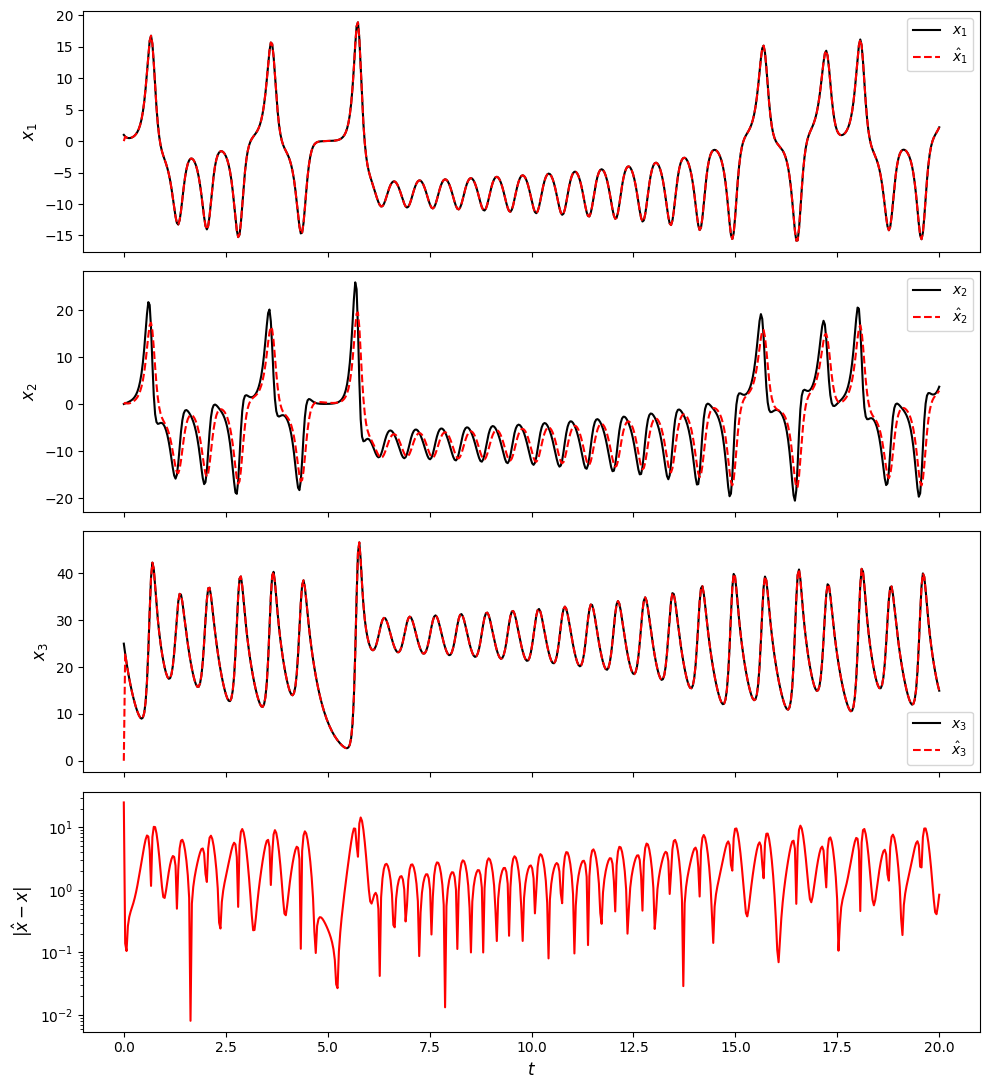

Figure saved to example3_observer.pdf


In [8]:
fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)

state_labels = [r"$x_1$",       r"$x_2$",       r"$x_3$"]
obs_labels   = [r"$\hat{x}_1$", r"$\hat{x}_2$", r"$\hat{x}_3$"]

for i, ax in enumerate(axes[:3]):
    ax.plot(t_sim, x_true3[i],           color="black", lw=1.5, label=state_labels[i])
    ax.plot(obs3["t"], obs3["x_hat"][i], color="red",   lw=1.5, ls="--", label=obs_labels[i])
    ax.set_ylabel(state_labels[i], fontsize=12)
    ax.legend(fontsize=10)

axes[3].semilogy(t_sim, np.maximum(err3, 1e-16), color="red", lw=1.5)
axes[3].set_ylabel(r"$|\hat{x} - x|$", fontsize=12)
axes[3].set_xlabel(r"$t$", fontsize=12)

plt.tight_layout()
plt.savefig("example3_observer.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to example3_observer.pdf")


## Timing summary

In [9]:
total = sum(timings.values())
print(f"{'Step':<30} {'Time (s)':>10} {'Share':>8}")
print("-" * 52)
for step, t in timings.items():
    print(f"{step:<30} {t:10.3f} {100*t/total:7.1f}%")
print("-" * 52)
print(f"{'Total':<30} {total:10.3f} {'100.0%':>8}")
print()
print("Active hyperparameters:")
for k, v in HP.items():
    print(f"  {k:<15} = {v}")

Step                             Time (s)    Share
----------------------------------------------------
1. Data collection                  5.449    64.3%
2. Kernel matrices                  0.044     0.5%
3. Observer synthesis               1.658    19.6%
4. Observer simulation              1.324    15.6%
----------------------------------------------------
Total                               8.475   100.0%

Active hyperparameters:
  lam             = 5.0
  tau             = 3.0
  n               = 64
  side_lengths    = [40.0, 52.0, 92.0]
  burn_in         = 10.0
  s               = 2.5
  length_scale    = 3.0
  k               = 10.0
  eps             = 0.01
  delta           = 1.0
  margin          = 0.01


## Hyperparameter Tuning Study

For each group the **remaining hyperparameters are held at their baseline values** (the `HP`
dictionary defined above).  Each 2-D grid cell reports the **ISE** ($\int_0^{30}|\hat x - x|^2\,dt$) for that combination.  
Grey cells with **✗** indicate synthesis failure or an unstable closed-loop matrix.  
The **baseline combination is highlighted with a white border** in each heatmap.

In [10]:
import itertools
from matplotlib.colors import LogNorm, Normalize

def run_sweep(hp_override, seed=0):
    """Run full pipeline with HP overridden by hp_override. Returns (status, max_re, ISE)."""
    hp = {**HP, **hp_override}
    try:
        t_eval_d = np.linspace(0.0, hp["tau"], 31)
        dat = sys3.collect_data(
            side_lengths=hp["side_lengths"], n=hp["n"],
            tau=hp["tau"], t_eval=t_eval_d,
            burn_in=hp.get("burn_in", 0.0),
            rng=np.random.default_rng(seed),
        )
        kap = linear_kernel() * sobolev_kernel(d=sys3.n_states, s=hp["s"], length_scale=hp["length_scale"])
        res = synthesize_observer_gain(
            dat, kap, lam=hp["lam"],
            k=hp["k"], eps=hp["eps"], delta=hp["delta"], margin=hp["margin"],
            verbose=False,
        )
        if res["status"] not in ("optimal", "optimal_inaccurate"):
            return res["status"], np.inf, np.inf
        A_cl = res["A"] - res["L"] @ dat.Y_data
        max_re = float(np.linalg.eigvals(A_cl).real.max())
        obs = simulate_koopman_observer(
            res, dat, y_func3, np.zeros(dat.n_samples),
            t_span=(t_sim[0], t_sim[-1]), t_eval=t_sim,
        )
        err = np.linalg.norm(obs["x_hat"] - x_true3, axis=0)
        ise = float(np.trapz(err**2, t_sim))
        return res["status"], max_re, ise
    except Exception as exc:
        return f"error", np.inf, np.inf


def heatmap(ax, row_vals, col_vals, grid, row_label, col_label,
            row_fmt=str, col_fmt=str, title=None,
            baseline_row=None, baseline_col=None, log_scale=True):
    """Draw a 2-D ISE or scalar heatmap on ax."""
    finite = grid[np.isfinite(grid)]
    if finite.size == 0:
        ax.text(0.5, 0.5, "all failed", transform=ax.transAxes, ha="center")
        return
    vmin, vmax = finite.min(), finite.max()
    if log_scale and vmin > 0:
        norm = LogNorm(vmin=max(vmin * 0.9, 1e-10), vmax=vmax * 1.1)
    else:
        pad = max(abs(vmax - vmin) * 0.05, 1e-10)
        norm = Normalize(vmin=vmin - pad, vmax=vmax + pad)

    cmap = plt.cm.RdYlGn_r.copy()
    cmap.set_bad("lightgrey")
    plot_data = np.where(np.isfinite(grid), grid, np.nan)
    im = ax.imshow(plot_data, aspect="auto", origin="lower", norm=norm, cmap=cmap)
    ax.set_xticks(range(len(col_vals))); ax.set_xticklabels([col_fmt(v) for v in col_vals])
    ax.set_yticks(range(len(row_vals))); ax.set_yticklabels([row_fmt(v) for v in row_vals])
    ax.set_xlabel(col_label); ax.set_ylabel(row_label)
    if title: ax.set_title(title, fontsize=9)
    for i in range(len(row_vals)):
        for j in range(len(col_vals)):
            v = grid[i, j]
            txt = f"{v:.4f}" if np.isfinite(v) else "✗"
            ax.text(j, i, txt, ha="center", va="center", fontsize=7, color="black")
    if baseline_row is not None and baseline_col is not None:
        from matplotlib.patches import Rectangle
        ax.add_patch(Rectangle(
            (baseline_col - 0.5, baseline_row - 0.5), 1, 1,
            fill=False, edgecolor="white", lw=2.5, zorder=5,
        ))
    plt.colorbar(im, ax=ax)


### Group 1 — Yosida parameters $(\lambda,\,\tau)$

$\lambda$ controls how closely the generator matrix $M$ approximates the Koopman generator;
$\tau$ is the trajectory length used to form $M$.
All other hyperparameters are held at their baseline values.

  [ 1/25]  lam=1.0    tau=1.0  max_re=-0.4446  ISE=350.3178  (optimal)
  [ 2/25]  lam=1.0    tau=2.0  max_re=-0.2519  ISE=338.8529  (optimal)
  [ 3/25]  lam=1.0    tau=3.0  max_re=-0.1855  ISE=333.7142  (optimal)
  [ 4/25]  lam=1.0    tau=5.0  max_re=-0.1507  ISE=331.2504  (optimal)
  [ 5/25]  lam=1.0    tau=10.0  max_re=-0.1303  ISE=326.2601  (optimal)
  [ 6/25]  lam=2.0    tau=1.0  max_re=-0.4664  ISE=315.4710  (optimal)
  [ 7/25]  lam=2.0    tau=2.0  max_re=-0.2869  ISE=308.1537  (optimal)
  [ 8/25]  lam=2.0    tau=3.0  max_re=-0.2587  ISE=307.7559  (optimal)
  [ 9/25]  lam=2.0    tau=5.0  max_re=-0.2460  ISE=309.0608  (optimal)
  [10/25]  lam=2.0    tau=10.0  max_re=-0.1669  ISE=304.9595  (optimal)
  [11/25]  lam=5.0    tau=1.0  max_re=-0.4519  ISE=276.0675  (optimal)
  [12/25]  lam=5.0    tau=2.0  max_re=-0.3877  ISE=274.0184  (optimal)
  [13/25]  lam=5.0    tau=3.0  max_re=-0.3262  ISE=277.1809  (optimal)
  [14/25]  lam=5.0    tau=5.0  max_re=-0.1745  ISE=278.1810  (optimal)
  [1

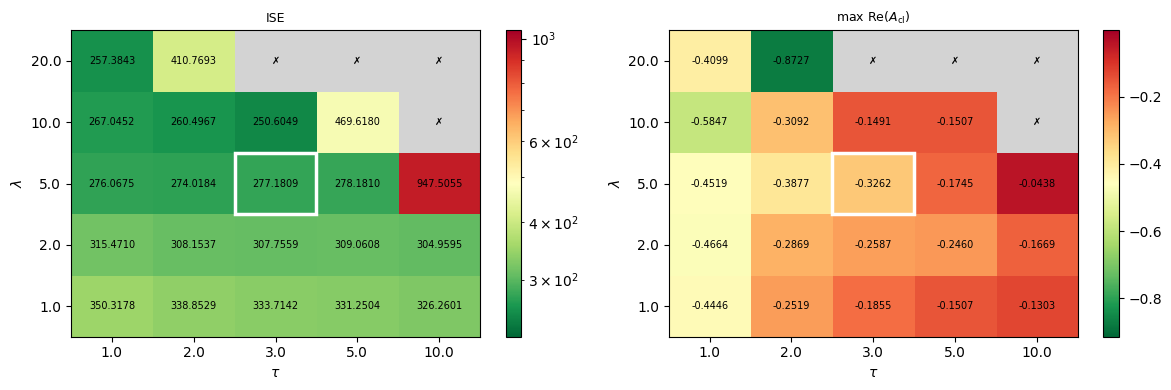

In [11]:
lam_vals = [1.0, 2.0, 5.0, 10.0, 20.0]
tau_vals  = [1.0, 2.0, 3.0, 5.0, 10.0]
g1_ise    = np.full((len(lam_vals), len(tau_vals)), np.nan)
g1_maxre  = np.full_like(g1_ise, np.nan)

total = len(lam_vals) * len(tau_vals)
for idx, (i, j) in enumerate(itertools.product(range(len(lam_vals)), range(len(tau_vals)))):
    ov = {"lam": lam_vals[i], "tau": tau_vals[j]}
    print(f"  [{idx+1:2d}/{total}]  lam={lam_vals[i]:<5}  tau={tau_vals[j]}", end="  ")
    st, mr, ise = run_sweep(ov)
    g1_ise[i, j]   = ise
    g1_maxre[i, j] = mr
    print(f"max_re={mr:+.4f}  ISE={ise:.4f}  ({st})")

bl_row1 = lam_vals.index(HP["lam"])
bl_col1 = tau_vals.index(HP["tau"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
heatmap(axes[0], lam_vals, tau_vals, g1_ise,
        r"$\lambda$", r"$\tau$", title="ISE",
        baseline_row=bl_row1, baseline_col=bl_col1, log_scale=True)
heatmap(axes[1], lam_vals, tau_vals, g1_maxre,
        r"$\lambda$", r"$\tau$", title=r"max Re$(A_{\mathrm{cl}})$",
        baseline_row=bl_row1, baseline_col=bl_col1, log_scale=False)
plt.tight_layout()
plt.savefig("example3_tuning_group1.pdf", dpi=150, bbox_inches="tight")
plt.show()


### Group 2 — Kernel parameters $(s,\,\ell)$

$s$ is the Sobolev index (controls smoothness of functions in the RKHS);
$\ell$ is the length scale of the Sobolev kernel.

In [12]:
s_vals   = [1.5, 2.0, 2.5, 3.0, 3.5]
ell_vals = [1.5, 2.0, 3.0, 5.0, 8.0]
g2_ise   = np.full((len(s_vals), len(ell_vals)), np.nan)
g2_maxre = np.full_like(g2_ise, np.nan)

total = len(s_vals) * len(ell_vals)
for idx, (i, j) in enumerate(itertools.product(range(len(s_vals)), range(len(ell_vals)))):
    ov = {"s": s_vals[i], "length_scale": ell_vals[j]}
    print(f"  [{idx+1}/{total}]  s={s_vals[i]:<4}  ell={ell_vals[j]}", end="  ")
    st, mr, ise = run_sweep(ov)
    g2_ise[i, j]   = ise
    g2_maxre[i, j] = mr
    print(f"max_re={mr:+.4f}  ISE={ise:.4f}  ({st})")

bl_row2 = s_vals.index(HP["s"])
bl_col2 = ell_vals.index(HP["length_scale"])

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
heatmap(ax, s_vals, ell_vals, g2_ise,
        r"$s$", r"$\ell$", title="ISE",
        baseline_row=bl_row2, baseline_col=bl_col2)
plt.tight_layout()
plt.savefig("example3_tuning_group2.pdf", dpi=150, bbox_inches="tight")
plt.show()


  [1/25]  s=1.5   ell=1.5  max_re=+inf  ISE=inf  (error)
  [2/25]  s=1.5   ell=2.0  max_re=+inf  ISE=inf  (error)
  [3/25]  s=1.5   ell=3.0  max_re=+inf  ISE=inf  (error)
  [4/25]  s=1.5   ell=5.0  max_re=+inf  ISE=inf  (error)
  [5/25]  s=1.5   ell=8.0  max_re=+inf  ISE=inf  (error)
  [6/25]  s=2.0   ell=1.5  max_re=-1.7548  ISE=417.9428  (optimal)
  [7/25]  s=2.0   ell=2.0  max_re=-1.3968  ISE=354.5438  (optimal)
  [8/25]  s=2.0   ell=3.0  max_re=-0.9887  ISE=290.4032  (optimal)
  [9/25]  s=2.0   ell=5.0  

KeyboardInterrupt: 

### Group 3 — LMI solution parameters $(\varepsilon,\,\delta,\,\text{margin})$

$\varepsilon$ regularises the Gram matrix ($G = K_0 + \varepsilon I$);
$\delta$ enforces $\tilde P \succ \delta I$;
**margin** sets the strict negativity margin in the LMI.  
One heatmap of $\varepsilon \times \delta$ is drawn for each value of **margin**.

  [1/48]  margin=1e-03  eps=1e-04  delta=0.01  

max_re=-0.2670  ISE=9988.7596  (optimal)
  [2/48]  margin=1e-03  eps=1e-04  delta=0.1  

max_re=-0.2670  ISE=9988.5514  (optimal)
  [3/48]  margin=1e-03  eps=1e-04  delta=1.0  

max_re=-0.2668  ISE=9989.9953  (optimal)
  [4/48]  margin=1e-03  eps=1e-04  delta=10.0  

max_re=-0.2656  ISE=9996.7167  (optimal)
  [5/48]  margin=1e-03  eps=1e-03  delta=0.01  

...

max_re=-0.2656  ISE=9996.6830  (optimal)
  [45/48]  margin=1e-01  eps=1e-01  delta=0.01  

max_re=-0.2669  ISE=9988.7421  (optimal)
  [46/48]  margin=1e-01  eps=1e-01  delta=0.1  

max_re=-0.2669  ISE=9988.5415  (optimal)
  [47/48]  margin=1e-01  eps=1e-01  delta=1.0  

max_re=-0.2668  ISE=9990.0034  (optimal)
  [48/48]  margin=1e-01  eps=1e-01  delta=10.0  

max_re=-0.2656  ISE=9996.8811  (optimal)


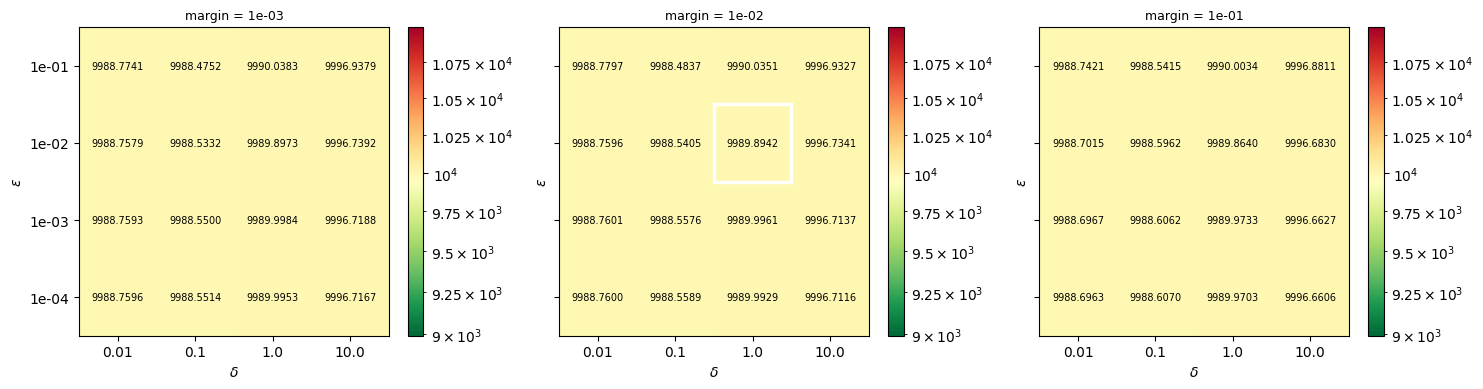

In [ ]:
eps_vals    = [1e-4, 1e-3, 1e-2, 1e-1]
delta_vals  = [1e-2, 1e-1,  1e0,  1e1]
margin_vals = [1e-3, 1e-2, 1e-1]

# g3_ise[k, i, j]  =  ISE for margin_vals[k], eps_vals[i], delta_vals[j]
g3_ise   = np.full((len(margin_vals), len(eps_vals), len(delta_vals)), np.nan)
g3_maxre = np.full_like(g3_ise, np.nan)

total = len(margin_vals) * len(eps_vals) * len(delta_vals)
for idx, (k, i, j) in enumerate(itertools.product(
        range(len(margin_vals)), range(len(eps_vals)), range(len(delta_vals)))):
    ov = {"eps": eps_vals[i], "delta": delta_vals[j], "margin": margin_vals[k]}
    print(f"  [{idx+1}/{total}]  margin={margin_vals[k]:.0e}  eps={eps_vals[i]:.0e}  delta={delta_vals[j]}", end="  ")
    st, mr, ise = run_sweep(ov)
    g3_ise[k, i, j]   = ise
    g3_maxre[k, i, j] = mr
    print(f"max_re={mr:+.4f}  ISE={ise:.4f}  ({st})")

bl_k = margin_vals.index(HP["margin"])
bl_i = eps_vals.index(HP["eps"])
bl_j = delta_vals.index(HP["delta"])

eps_fmt    = lambda v: f"{v:.0e}"
delta_fmt  = lambda v: str(v)
margin_fmt = lambda v: f"{v:.0e}"

fig, axes = plt.subplots(1, len(margin_vals), figsize=(5 * len(margin_vals), 4), sharey=True)
for k, ax in enumerate(axes):
    br = bl_i if k == bl_k else None
    bc = bl_j if k == bl_k else None
    heatmap(ax, eps_vals, delta_vals, g3_ise[k],
            r"$\varepsilon$", r"$\delta$",
            row_fmt=eps_fmt, col_fmt=delta_fmt,
            title=f"margin = {margin_fmt(margin_vals[k])}",
            baseline_row=br, baseline_col=bc)
plt.tight_layout()
plt.savefig("example3_tuning_group3.pdf", dpi=150, bbox_inches="tight")
plt.show()


### Group 4 — Forcing constant $k$

$k$ appears in the LMI as the weight on the output term $k X^\top X$
(paper Eq. 19).  Larger $k$ penalises the output approximation error more strongly.

  [1/9]  k=0.1  

max_re=-0.2637  ISE=10007.7453  (optimal)
  [2/9]  k=0.237  

max_re=-0.2645  ISE=10021.5700  (optimal)
  [3/9]  k=0.562  

max_re=-0.2654  ISE=10009.8180  (optimal)
  [4/9]  k=1.33  

max_re=-0.2662  ISE=10003.4282  (optimal)
  [5/9]  k=3.16  

max_re=-0.2667  ISE=9998.2204  (optimal)
  [6/9]  k=7.5  

max_re=-0.2669  ISE=9994.4782  (optimal)
  [7/9]  k=17.8  

max_re=-0.2667  ISE=9985.4380  (optimal)
  [8/9]  k=42.2  

max_re=-0.2668  ISE=9982.3559  (optimal)
  [9/9]  k=100  

max_re=-0.2671  ISE=9983.1022  (optimal)


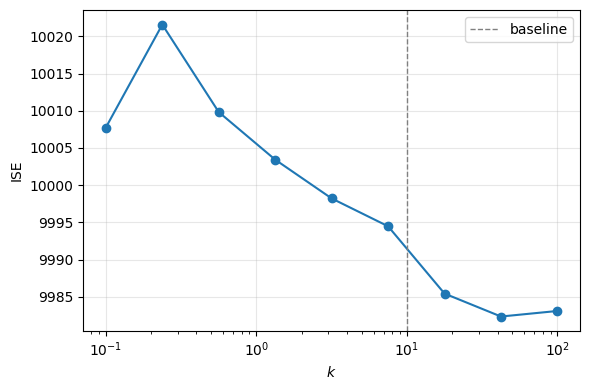

In [ ]:
k_vals  = np.logspace(-1, 2, 9)
g4_ise  = []
g4_maxre = []

for idx, kv in enumerate(k_vals):
    print(f"  [{idx+1}/{len(k_vals)}]  k={kv:.3g}", end="  ")
    st, mr, ise = run_sweep({"k": kv})
    g4_ise.append(ise); g4_maxre.append(mr)
    print(f"max_re={mr:+.4f}  ISE={ise:.4f}  ({st})")

fig, ax = plt.subplots(figsize=(6, 4))
finite = [(kv, v) for kv, v in zip(k_vals, g4_ise) if np.isfinite(v)]
if finite:
    xs, ys = zip(*finite)
    ax.plot(xs, ys, "o-", color="C0")
ax.axvline(HP["k"], color="grey", ls="--", lw=1, label="baseline")
ax.set_xscale("log"); ax.set_xlabel("$k$"); ax.set_ylabel("ISE")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("example3_tuning_group4.pdf", dpi=150, bbox_inches="tight")
plt.show()


### Group 5 — Number of data points $n$

$n$ determines the size of the RKHS basis.  Larger $n$ reduces the RKHS
approximation bias but increases the cost of the LMI solve ($O(n^3)$) and
the observer ODE ($O(n^2)$).

  [1/10]  n=16  

max_re=-0.8555  ISE=7433.2035  (optimal)
  [2/10]  n=20  

max_re=-0.5645  ISE=7613.8127  (optimal)
  [3/10]  n=25  

max_re=-0.5303  ISE=7110.5355  (optimal)
  [4/10]  n=32  

max_re=-0.4722  ISE=7605.2706  (optimal)
  [5/10]  n=40  

...

max_re=-0.3509  ISE=8381.7894  (optimal)
  [7/10]  n=64  

max_re=-0.2668  ISE=9989.8942  (optimal)
  [8/10]  n=80  

max_re=-0.2519  ISE=8903.0763  (optimal)
  [9/10]  n=101  

max_re=-0.2001  ISE=9820.0778  (optimal)
  [10/10]  n=128  

max_re=-0.1343  ISE=6288.3948  (optimal)


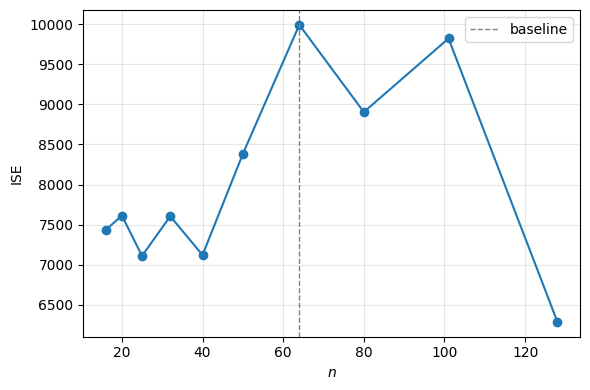

In [ ]:
n_vals   = [int(2**a) for a in np.linspace(4, 7, 10)]
g5_ise   = []
g5_maxre = []

for idx, nv in enumerate(n_vals):
    print(f"  [{idx+1}/{len(n_vals)}]  n={nv}", end="  ")
    st, mr, ise = run_sweep({"n": nv})
    g5_ise.append(ise); g5_maxre.append(mr)
    print(f"max_re={mr:+.4f}  ISE={ise:.4f}  ({st})")

fig, ax = plt.subplots(figsize=(6, 4))
finite = [(nv, v) for nv, v in zip(n_vals, g5_ise) if np.isfinite(v)]
if finite:
    xs, ys = zip(*finite)
    ax.plot(xs, ys, "o-", color="C0")
ax.axvline(HP["n"], color="grey", ls="--", lw=1, label="baseline")
ax.set_xlabel("$n$"); ax.set_ylabel("ISE")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("example3_tuning_group5.pdf", dpi=150, bbox_inches="tight")
plt.show()


## Comparison with Alternative Observers

All observers below share the **same deterministic design criterion** with the same $k$ as in `HP`.
The output is $y = (x_1, x_3)^\top$, making the system **fully linearly observable** (rank$(\mathcal{O})=3$).

| Observer | State model | Notes |
|---|---|---|
| **Koopman–Luenberger** | RKHS Koopman generator (data-driven) | $\tilde P A + A^\top \tilde P - \tilde Y H - H^\top \tilde Y^\top + k X^\top X \preceq 0$ |
| **Linear model-based Luenberger** | Jacobian at origin (unstable) | LMI on $3\times 3$ linearised system, $C=[e_1,e_3]^\top$ |
| **Nonlinear model-based Luenberger** | Full Lorenz $f$ | Uses same gain $L_{\mathrm{lin}}$ applied to $y - h(\hat x)$ |

All observers start from $\hat x_0 = 0$.


In [13]:
import cvxpy as cp

# ── Linearised system at x* = (0,0,0) ────────────────────────────────────────
A_lin = np.array([[-10., 10.,  0.  ],
                  [ 28., -1.,  0.  ],
                  [  0.,  0., -8./3.]])
C_lin = np.array([[1., 0., 0.],    # y1 = x1
                  [0., 0., 1.]])   # y2 = x3   — shape (2, 3)
d_lin = 3

# ── LMI design on linearised system (2 outputs) ───────────────────────────────
k_lin = HP["k"]; delta_lin = HP["delta"]; mar_lin = HP["margin"]

P_v = cp.Variable((d_lin, d_lin), symmetric=True)
Y_v = cp.Variable((d_lin, 2))   # 2 outputs

lmi_lin = (P_v @ A_lin + A_lin.T @ P_v
           - Y_v @ C_lin - C_lin.T @ Y_v.T
           + k_lin * np.eye(d_lin))

prob_lin = cp.Problem(
    cp.Minimize(cp.trace(P_v)),
    [lmi_lin << -mar_lin * np.eye(d_lin),
     P_v    >> delta_lin * np.eye(d_lin)],
)
prob_lin.solve(solver="MOSEK", verbose=False)

P_lin = P_v.value
Y_lin = Y_v.value
L_lin = np.linalg.solve(P_lin, Y_lin)   # (3, 2)

A_cl_lin = A_lin - L_lin @ C_lin
print(f"Linear LMI status           : {prob_lin.status}")
print(f"Linear LMI gain L_lin (3×2) :\n{L_lin}")
print(f"Linear LMI closed-loop eigs : {np.sort(np.linalg.eigvals(A_cl_lin).real)}")

# ── Simulate: Linear model-based Luenberger ────────────────────────────────────
x0_obs = np.zeros(3)

def lin_lmi_rhs(t, xh):
    yt = y_func3(t)                          # (2,)
    return A_lin @ xh + L_lin @ (yt - C_lin @ xh)

sol_lin = solve_ivp(lin_lmi_rhs, [t_sim[0], t_sim[-1]], x0_obs,
                    method="Radau", rtol=1e-8, atol=1e-10, t_eval=t_sim)

# ── Simulate: Nonlinear model-based Luenberger ─────────────────────────────────
def naive_rhs(t, xh):
    yt = y_func3(t)                          # (2,)
    return f_ex3(xh) + L_lin @ (yt - sys3.output(xh))

sol_naive = solve_ivp(naive_rhs, [t_sim[0], t_sim[-1]], x0_obs,
                      method="Radau", rtol=1e-8, atol=1e-10, t_eval=t_sim)

# ── Error norms and ISE ────────────────────────────────────────────────────────
err_koop  = np.linalg.norm(obs3["x_hat"] - x_true3, axis=0)
err_lin   = np.linalg.norm(sol_lin.y     - x_true3, axis=0)
err_naive = np.linalg.norm(sol_naive.y   - x_true3, axis=0)

ise_koop  = float(np.trapz(err_koop**2, t_sim))
ise_lin   = float(np.trapz(err_lin**2,  t_sim))
ise_naive = float(np.trapz(err_naive**2,t_sim))

print(f"\n{'Observer':<35} {'ISE':>10}")
print("-" * 47)
for name, ise in [("Koopman–Luenberger", ise_koop),
                  ("Linear model-based Luenberger",    ise_lin),
                  ("Nonlinear model-based Luenberger", ise_naive)]:
    print(f"  {name:<33} {ise:10.4f}")


Linear LMI status           : optimal
Linear LMI gain L_lin (3×2) :
[[-2.71762602 -0.        ]
 [39.62010033 -0.        ]
 [-0.          2.80177299]]
Linear LMI closed-loop eigs : [-5.46843966 -4.14118699 -4.14118699]

Observer                                   ISE
-----------------------------------------------
  Koopman–Luenberger                  277.1809
  Linear model-based Luenberger     21579.6599
  Nonlinear model-based Luenberger     57.5351


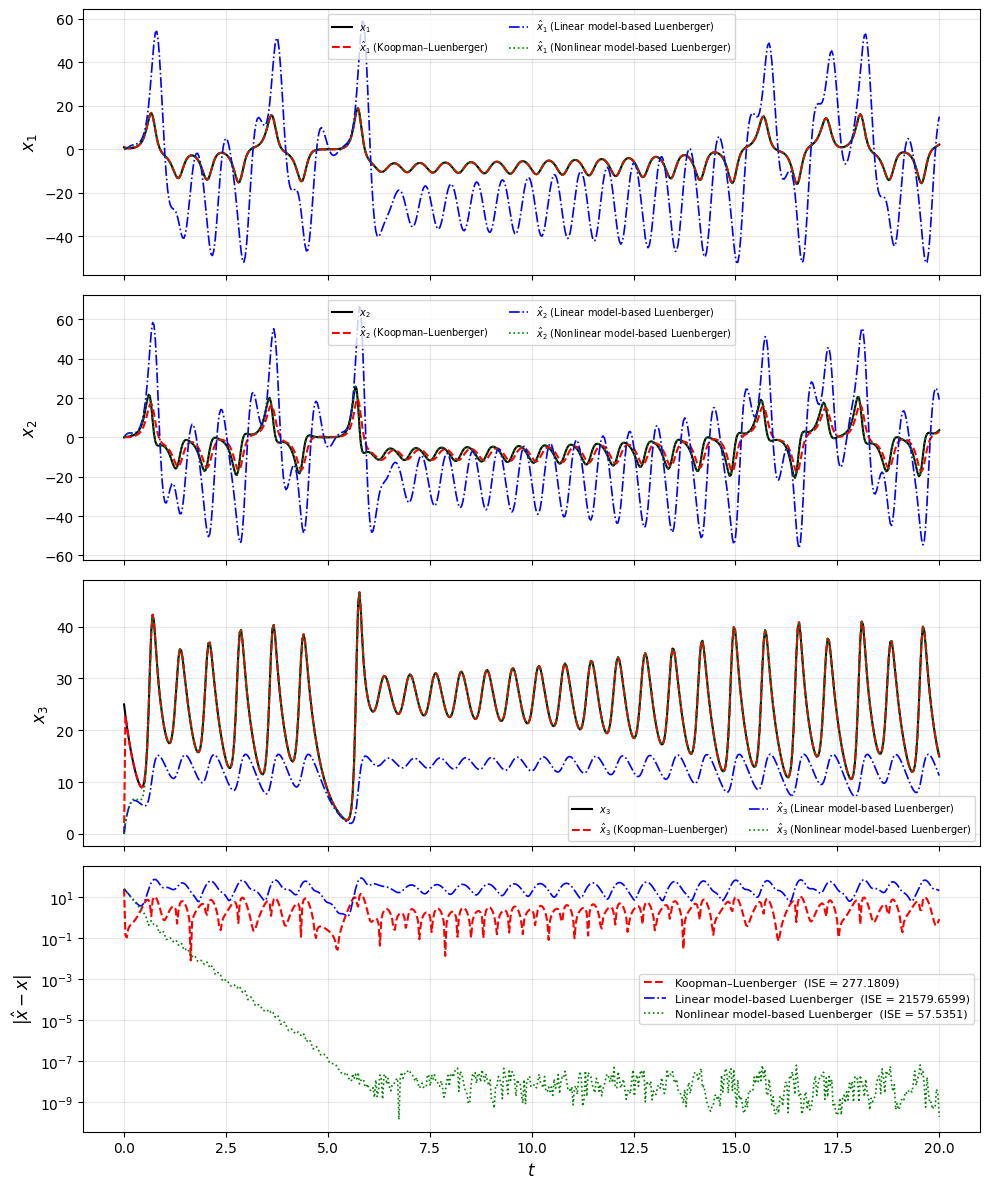

Figure saved to example3_comparison.pdf


In [14]:
styles = {
    "True":                              dict(color="black",     lw=1.5, ls="-"),
    "Koopman\u2013Luenberger":          dict(color="red",       lw=1.5, ls="--"),
    "Linear model-based Luenberger":     dict(color="blue",      lw=1.2, ls="-."),
    "Nonlinear model-based Luenberger":  dict(color="green",     lw=1.2, ls=":"),
}
xhats = {
    "Koopman\u2013Luenberger":          obs3["x_hat"],
    "Linear model-based Luenberger":     sol_lin.y,
    "Nonlinear model-based Luenberger":  sol_naive.y,
}
ises = {
    "Koopman\u2013Luenberger":          ise_koop,
    "Linear model-based Luenberger":     ise_lin,
    "Nonlinear model-based Luenberger":  ise_naive,
}
errs = {
    "Koopman\u2013Luenberger":          err_koop,
    "Linear model-based Luenberger":     err_lin,
    "Nonlinear model-based Luenberger":  err_naive,
}

state_syms = [r"$x_1$", r"$x_2$", r"$x_3$"]
hat_syms   = [r"$\hat{x}_1$", r"$\hat{x}_2$", r"$\hat{x}_3$"]

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i, ax in enumerate(axes[:3]):
    ax.plot(t_sim, x_true3[i], label=state_syms[i], **styles["True"])
    for name, xh in xhats.items():
        ax.plot(t_sim, xh[i], label=f"{hat_syms[i]} ({name})", **styles[name])
    ax.set_ylabel(state_syms[i], fontsize=12)
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

for name, er in errs.items():
    axes[3].semilogy(t_sim, np.maximum(er, 1e-16),
                     label=f"{name}  (ISE = {ises[name]:.4f})",
                     **styles[name])
axes[3].set_ylabel(r"$|\hat{x} - x|$", fontsize=12)
axes[3].set_xlabel(r"$t$", fontsize=12)
axes[3].legend(fontsize=8); axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("example3_comparison.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to example3_comparison.pdf")


## Comparison with Neural-Network KKL Observer

The **KKL observer** coordinate map $T: x \mapsto z$ satisfies
$$\frac{\partial T}{\partial x}\,f(x) = D\,T(x) + E\,h(x)$$
with $D$ stable and $h(x) = (x_1, x_3)^\top$.  Online: run $\dot z = Dz + Ey(t)$, recover $\hat x = T^\dagger(z)$.

Both maps are MLPs trained on the **same $n=64$ trajectory data** (`data3`).

| Parameter | Value |
|---|---|
| $D$ | diag$(-1,-2,-3)$ |
| $E$ | $\begin{pmatrix}1&0\\0&1\\1&1\end{pmatrix}\in\mathbb{R}^{3\times 2}$ |
| Embedding dim $q$ | 3 |
| MLP architecture | 2 hidden layers, 32 units, tanh |


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.interpolate import interp1d

# ── KKL hyperparameters ────────────────────────────────────────────────────────
KKL_HP = {
    "q":       3,                    # embedding dimension (= state dim)
    "D_eigs":  [-1., -2., -3.],     # eigenvalues of D (must be stable)
    "E":       [[1., 0.],            # E ∈ R^{q×2}: z1 ← y1=x1
                [0., 1.],            #               z2 ← y2=x3
                [1., 1.]],           #               z3 ← y1+y2
    "width":   32,
    "depth":   2,
    "lr":      1e-3,
    "epochs":  5000,
}

# ── Build KKL matrices ─────────────────────────────────────────────────────────
q_kkl = KKL_HP["q"]
D_kkl = np.diag(KKL_HP["D_eigs"])          # (3, 3)
E_kkl = np.array(KKL_HP["E"])              # (3, 2)

# ── Generate z(t) for each training trajectory (z(0)=0) ───────────────────────
n_traj = data3.n_samples
t_data = np.linspace(0., HP["tau"], 31)

print("Generating z training data …")
t0_kkl = time.perf_counter()

z_traj = np.zeros((q_kkl, 31, n_traj))
for i in range(n_traj):
    y_i = data3.Y_traj[:, :, i]           # (2, 31)  — both outputs
    y_interp = interp1d(t_data, y_i, kind="cubic", fill_value="extrapolate")

    def _rhs(t, z, _yi=y_interp):
        return D_kkl @ z + E_kkl @ _yi(t)  # (3,) = (3,3)@(3,) + (3,2)@(2,)

    sol_z = solve_ivp(_rhs, [0., HP["tau"]], np.zeros(q_kkl),
                      method="Radau", t_eval=t_data, rtol=1e-8, atol=1e-10)
    z_traj[:, :, i] = sol_z.y

timings["KKL data"] = time.perf_counter() - t0_kkl
print(f"  done in {timings['KKL data']:.2f}s")

X_train_kkl = data3.X_traj.reshape(sys3.n_states, -1).T  # (1984, 3)
Z_train_kkl = z_traj.reshape(q_kkl, -1).T                # (1984, 3)
print(f"Training pairs: {X_train_kkl.shape[0]}")


Generating z training data …
  done in 3.07s
Training pairs: 1984


In [16]:
torch.manual_seed(42)

class ZeroAtOriginMLP(nn.Module):
    """MLP with T(0)=0 enforced by subtracting the network's own value at 0."""
    def __init__(self, in_dim, out_dim, width, depth):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x0 = torch.zeros(1, x.shape[-1], dtype=x.dtype, device=x.device)
        return self.net(x) - self.net(x0)

d_state = sys3.n_states   # 3
T_net    = ZeroAtOriginMLP(d_state, q_kkl, KKL_HP["width"], KKL_HP["depth"])
Tinv_net = ZeroAtOriginMLP(q_kkl, d_state, KKL_HP["width"], KKL_HP["depth"])

X_t = torch.tensor(X_train_kkl, dtype=torch.float32)
Z_t = torch.tensor(Z_train_kkl, dtype=torch.float32)
loss_fn = nn.MSELoss()

def _train(net, x_in, y_tgt, label):
    opt = optim.Adam(net.parameters(), lr=KKL_HP["lr"])
    ep_print = KKL_HP["epochs"] // 4
    for ep in range(KKL_HP["epochs"]):
        opt.zero_grad()
        loss = loss_fn(net(x_in), y_tgt)
        loss.backward()
        opt.step()
        if (ep + 1) % ep_print == 0:
            print(f"  {label}  ep {ep+1:5d}  loss = {loss.item():.6f}")
    return loss.item()

print("Training T  (x → z) …")
t0_T = time.perf_counter()
loss_T = _train(T_net, X_t, Z_t, "T   ")
timings["KKL train T"] = time.perf_counter() - t0_T
print(f"  final MSE = {loss_T:.6f}  ({timings['KKL train T']:.1f}s)")

print(""); print("Training T⁻¹ (z → x) …")
t0_Ti = time.perf_counter()
loss_Ti = _train(Tinv_net, Z_t, X_t, "T⁻¹")
timings["KKL train Tinv"] = time.perf_counter() - t0_Ti
print(f"  final MSE = {loss_Ti:.6f}  ({timings['KKL train Tinv']:.1f}s)")

# Sanity check: T(0) and T†(0) must both be [0,0,0] by construction
with torch.no_grad():
    print(f"T(0)  = {T_net(torch.zeros(1, d_state)).numpy().ravel()}")
    print(f"T†(0) = {Tinv_net(torch.zeros(1, q_kkl)).numpy().ravel()}")


Training T  (x → z) …
  T     ep  1250  loss = 6.200275
  T     ep  2500  loss = 5.959645
  T     ep  3750  loss = 5.803525
  T     ep  5000  loss = 5.636563
  final MSE = 5.636563  (4.1s)

Training T⁻¹ (z → x) …
  T⁻¹  ep  1250  loss = 38.474327
  T⁻¹  ep  2500  loss = 31.778814
  T⁻¹  ep  3750  loss = 27.874311
  T⁻¹  ep  5000  loss = 25.490051
  final MSE = 25.490051  (3.8s)
T(0)  = [0. 0. 0.]
T†(0) = [0. 0. 0.]


KKL observer ISE = 1531.2019


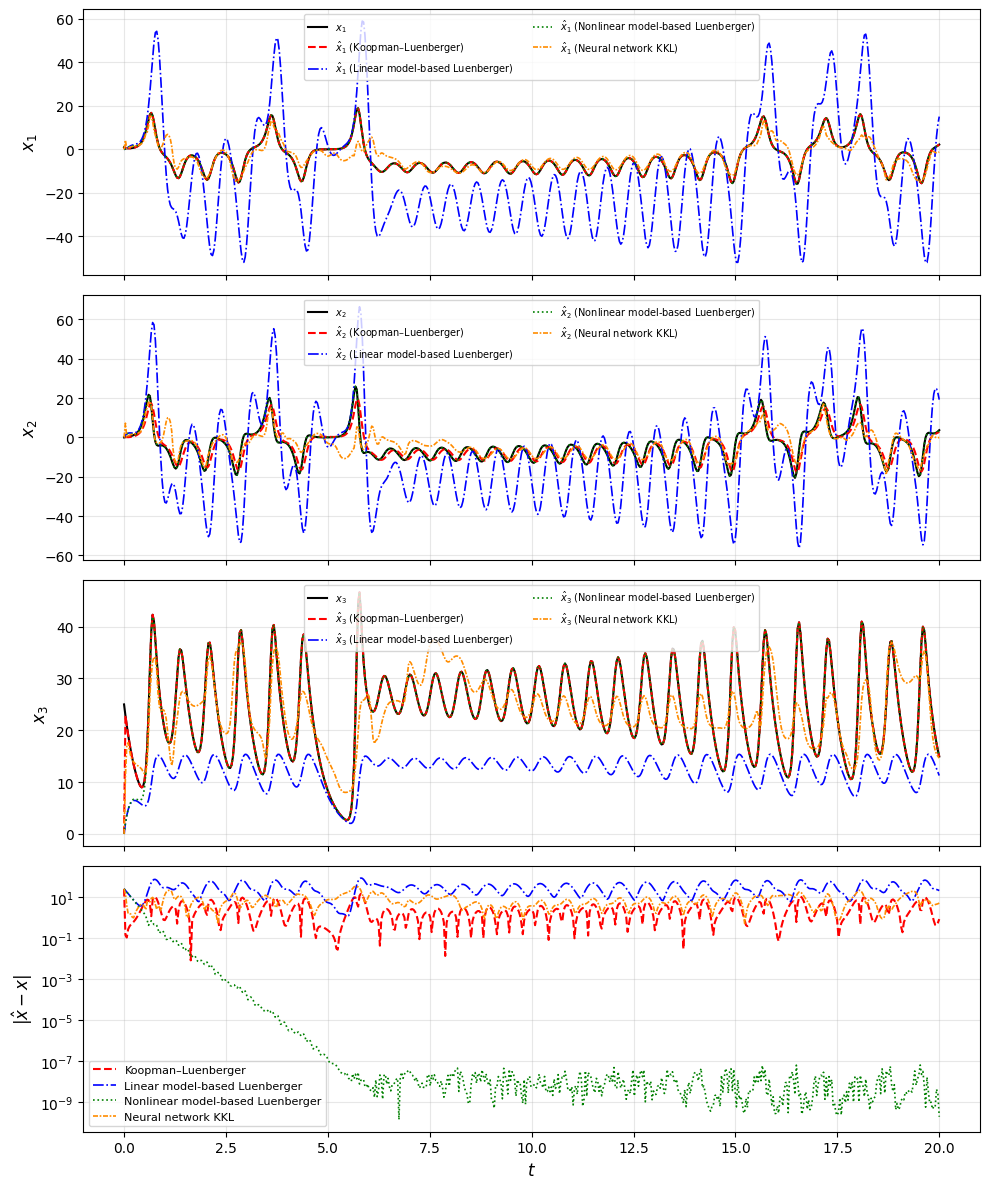


Figure saved to example3_comparison_kkl.pdf

Observer                                   ISE
-----------------------------------------------
  Koopman–Luenberger                  277.1809
  Linear model-based Luenberger     21579.6599
  Nonlinear model-based Luenberger     57.5351
  Neural network KKL                 1531.2019


In [17]:
# ── KKL observer simulation ────────────────────────────────────────────────────
def _kkl_rhs(t, z):
    return D_kkl @ z + E_kkl @ y_func3(t)   # y_func3 returns (2,)

t0_ks = time.perf_counter()
sol_kkl_z = solve_ivp(_kkl_rhs, [t_sim[0], t_sim[-1]], np.zeros(q_kkl),
                      method="Radau", rtol=1e-8, atol=1e-10, t_eval=t_sim)
timings["KKL simulate"] = time.perf_counter() - t0_ks

with torch.no_grad():
    Z_sim_t  = torch.tensor(sol_kkl_z.y.T, dtype=torch.float32)
    xhat_kkl = Tinv_net(Z_sim_t).numpy().T   # (3, N_sim)

err_kkl = np.linalg.norm(xhat_kkl - x_true3, axis=0)
ise_kkl = float(np.trapz(err_kkl**2, t_sim))
print(f"KKL observer ISE = {ise_kkl:.4f}")

# ── Combined comparison plot ────────────────────────────────────────────────────
styles4 = {
    "True":                              dict(color="black",     lw=1.5, ls="-"),
    "Koopman–Luenberger":          dict(color="red",       lw=1.5, ls="--"),
    "Linear model-based Luenberger":     dict(color="blue",      lw=1.2, ls="-."),
    "Nonlinear model-based Luenberger":  dict(color="green",     lw=1.2, ls=":"),
    "Neural network KKL":                dict(color="darkorange",lw=1.2, ls=(0,(3,1,1,1))),
}
xhats4 = {
    "Koopman–Luenberger":          obs3["x_hat"],
    "Linear model-based Luenberger":     sol_lin.y,
    "Nonlinear model-based Luenberger":  sol_naive.y,
    "Neural network KKL":                xhat_kkl,
}
ises4 = {
    "Koopman–Luenberger":          ise_koop,
    "Linear model-based Luenberger":     ise_lin,
    "Nonlinear model-based Luenberger":  ise_naive,
    "Neural network KKL":                ise_kkl,
}
errs4 = {
    "Koopman–Luenberger":          err_koop,
    "Linear model-based Luenberger":     err_lin,
    "Nonlinear model-based Luenberger":  err_naive,
    "Neural network KKL":                err_kkl,
}

state_syms = [r"$x_1$", r"$x_2$", r"$x_3$"]
hat_syms   = [r"$\hat{x}_1$", r"$\hat{x}_2$", r"$\hat{x}_3$"]

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i, ax in enumerate(axes[:3]):
    ax.plot(t_sim, x_true3[i], label=state_syms[i], **styles4["True"])
    for name, xh in xhats4.items():
        ax.plot(t_sim, xh[i], label=f"{hat_syms[i]} ({name})", **styles4[name])
    ax.set_ylabel(state_syms[i], fontsize=12)
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

for name, er in errs4.items():
    axes[3].semilogy(t_sim, np.maximum(er, 1e-16),
                     label=name, **styles4[name])
axes[3].set_ylabel(r"$|\hat{x} - x|$", fontsize=12)
axes[3].set_xlabel(r"$t$", fontsize=12)
axes[3].legend(fontsize=8); axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("example3_comparison_kkl.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure saved to example3_comparison_kkl.pdf")
print(f"\n{'Observer':<35} {'ISE':>10}")
print("-" * 47)
for name, ise in ises4.items():
    print(f"  {name:<33} {ise:10.4f}")
